**Description:**

This section implements a quantitative framework to grade each Reverse LBP event. We measure four key aspects of a successful launch and normalize them onto a standard **0-100 Score**.

To prevent negative scores, all formulas use a "floor" logic: `Score = max(0, Formula)`. This means extreme failures result in a 0, not a negative number.

#### 1. Bot & Frontrunning Resistance

* **The Goal:** Prevent snipers from stealing value in the first few blocks.
* **The Formula:** $$Score = 100 - (2 \times \% \text{SniperVolume})$$

* **The Logic (Why $\times 2$?):**
We define **50% Bot Volume** as a total failure. If half the liquidity is taken by bots ($50 \times 2 = 100$), the score drops to **0**.

#### 2. Fair Value Discovery

* **The Goal:** The price should stabilize after the LBP ends, finding a true "fair market value."
* **The Formula:** $$Score = 100 - (200 \times \text{PriceDeviation})$$

* **The Logic (Why $\times 200$?):**
We define a **50% Price Crash** (or Pump) as a total failure. If the price moves 50% ($0.50$) immediately after the event, the score hits **0** ($0.50 \times 200 = 100$ penalty).

#### 3. Market Stability

* **The Goal:** Sell tokens smoothly without causing chaotic volatility per trade.
* **The Formula:** $$Score = 100 - (1000 \times \text{Volatility})$$

* **The Logic (Why $\times 1000$?):**
Volatility is usually a tiny number (e.g., 0.01). We define **10% Volatility** per trade as "Chaos." If volatility hits 0.10, the score drops to **0** ($0.10 \times 1000 = 100$ penalty).

#### 4. Cost Efficiency

* **The Goal:** Provide better execution prices (lower slippage) than a standard sale.
* **The Formula:** $$Score = 100 - (2000 \times \text{AvgImpact})$$

* **The Logic (Why $\times 2000$?):**
We define **5% Average Slippage** as unusable liquidity. If the average user loses 5% ($0.05$) on a trade, the pool is inefficient and the score hits **0** ($0.05 \times 2000 = 100$ penalty).

#### 5. Execution Differential (vs. External Market)

* **The Goal:** Ensure the protocol is buying back tokens cheaper than the open market (CEX/DEX) price.
* **The Formula:** $$Score = 50 + (100 \times \% \text{DiscountObtained})$$

* **The Logic (Why Start at 50?):**
This metric is centered around zero.
* **0% Discount (Parity):** Score = 50 (Neutral execution).
* **+5% Discount:** Score = 50 + (100 * 0.05) = 55 (Good execution).
* **-5% Premium:** Score = 50 + (100 * -0.05) = 45 (Bad execution).
* **-50% Premium:** Score = 0 (Total Failure).

#### 6. Markout Analysis (1H Inventory PnL)

* **The Goal:** Avoid "toxic flow" (buying just before the price dumps). A positive markout means the buy was timed well (buying the dip).
* **The Formula:** $$Score = 50 + (200 \times \% \text{MarkoutPnL})$$

* **The Logic (Why $\times 200$?):**
* **0% Markout:** Score = 50 (Price stayed flat after buy).
* **+2.5% Markout:** Score = 50 + (200 * 0.025) = 55 (We bought the bottom).
* **-25% Markout:** Score = 0 (We bought the exact top before a crash).

#### 7. Source Toxicity (Flow Quality)

* **The Goal:** Minimize buying from MEV bots (toxic/arbitrage) and maximize buying from Aggregators (organic/user).
* **The Formula:** $$Score = 100 - (100 \times \% \text{MEVVolume})$$

* **The Logic (Why $\times 100$?):**
We define **100% MEV Volume** as a fully captured/toxic pool.
* **0% MEV:** Score = 100 (Pure organic flow).
* **30% MEV:** Score = 70 (Acceptable leakage).
* **100% MEV:** Score = 0 (The pool existed only to feed arbitrage bots).

# Imports

In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import yfinance as yf
from web3 import Web3
from datetime import datetime, timedelta

# Constants

In [2]:
# ==========================================
# 1. CONFIGURATION
# ==========================================
V1V2_POOLS_FILE = "../../../media/dune_web_downloads/rLBPs/dev_rLBPs_Final_cleaned_pools_addresses.csv"
V1V2_TRADES_FILE = "../../../media/dune_web_downloads/rLBPs/dev_rLBPs_Final_trades.csv"
V1V2_MARKET_FILE = "../../../media/dune_web_downloads/rLBPs/dev_rLBPs_Final_market_values.csv"

# Known Decimals
DECIMALS = {
    'USDC': 6, 'USDT': 6, 'DAI': 18, 'WETH': 18, 'BAL': 18,
    'MIM': 18, 'FRAX': 18, 'LUSD': 18
}

# Analysis

## Spot price

### Theorical spot price curve (without swaps)

Initializing Data...
 > Fetching ETH-USD history from 2020-01-01 to 2023-01-01...

Generating Theoretical Curve for: WETH_LBP_0x4693


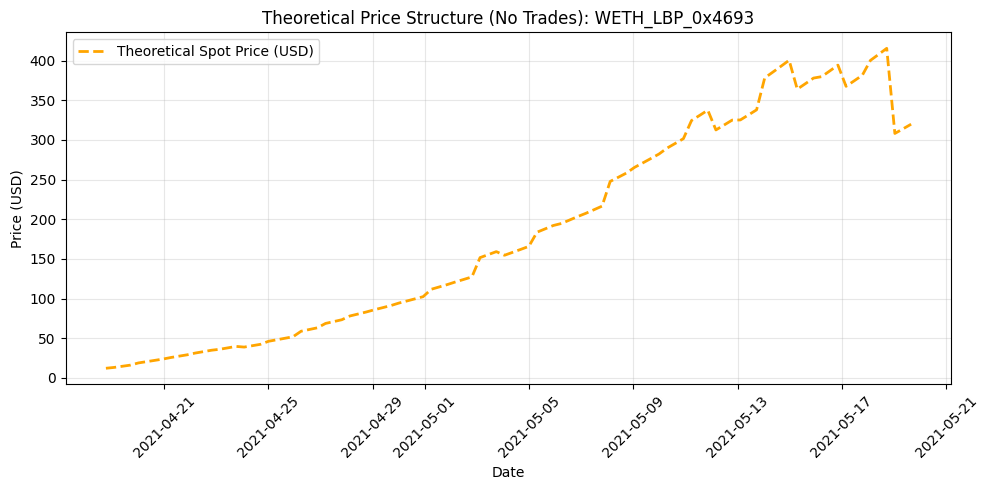


Generating Theoretical Curve for: WETH_LBP_0xa4a8


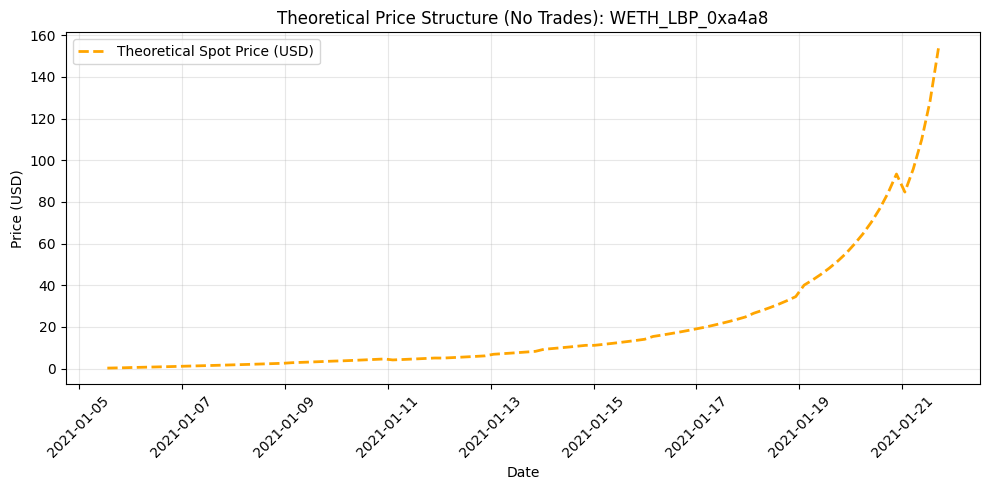


Generating Theoretical Curve for: DAI_LBP_0x174c


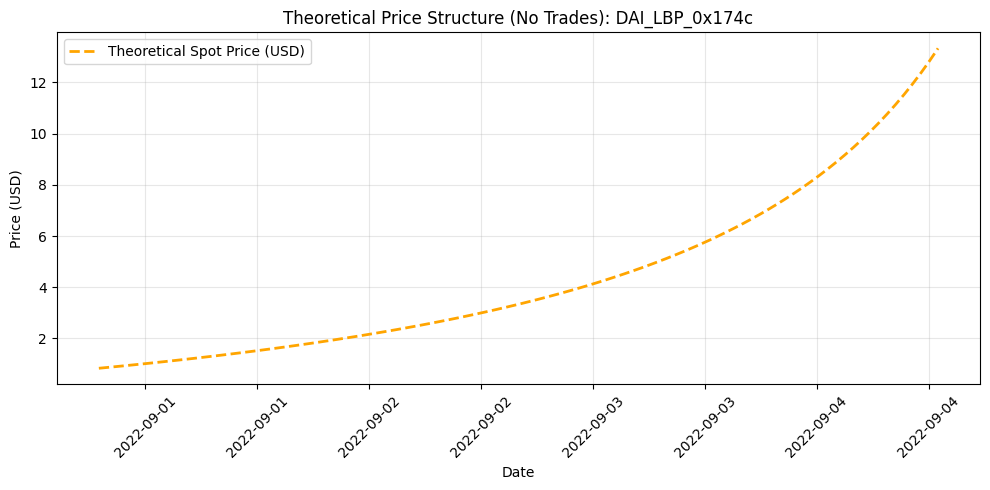


Generating Theoretical Curve for: DAI_LBP_0xbaed


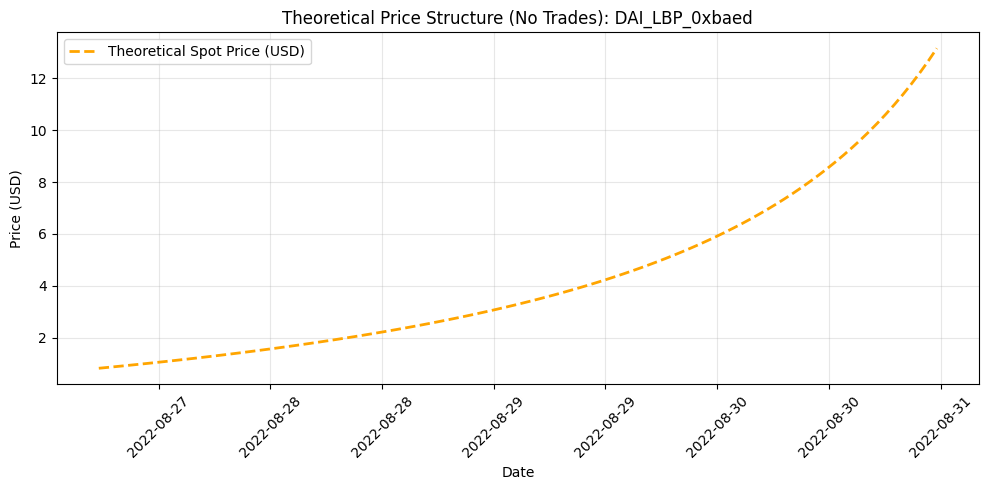


Generating Theoretical Curve for: DAI_LBP_0xd328


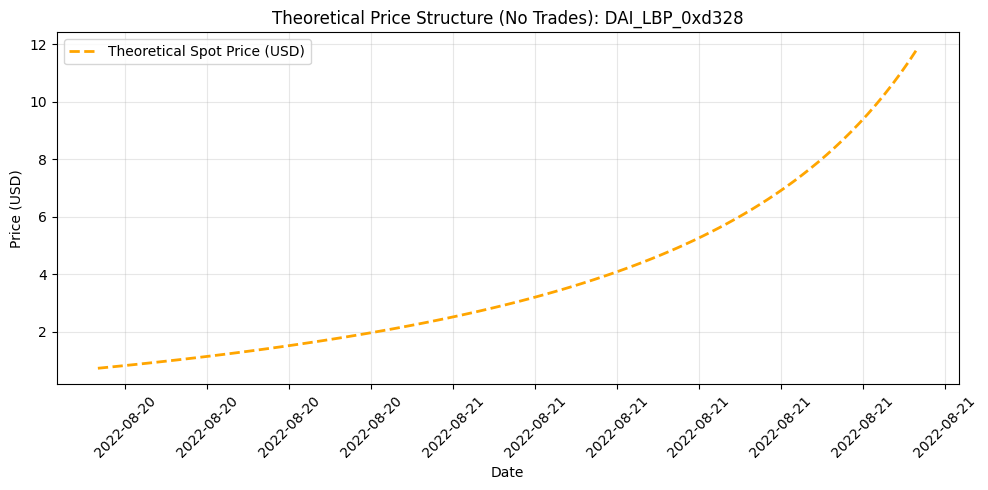


Generating Theoretical Curve for: DAI_LBP_0xe11b


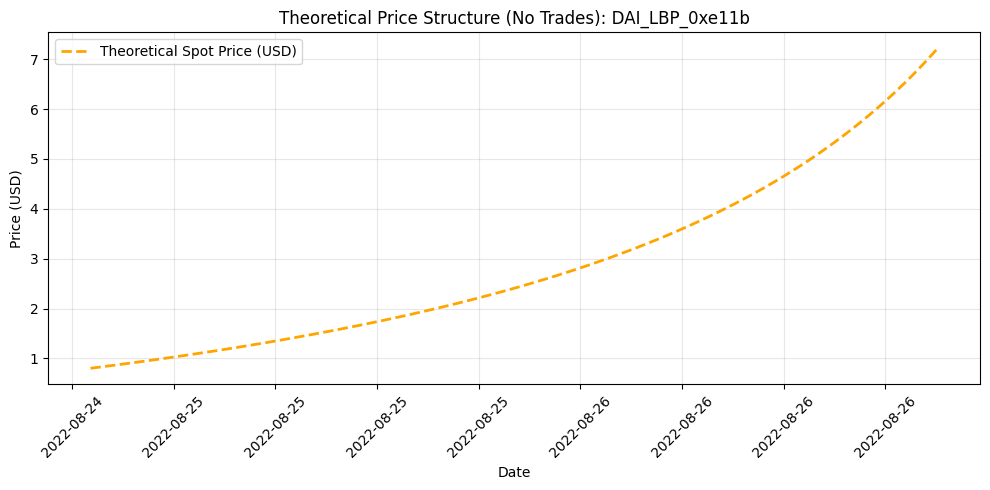


Generating Theoretical Curve for: DAI_LBP_0xf812


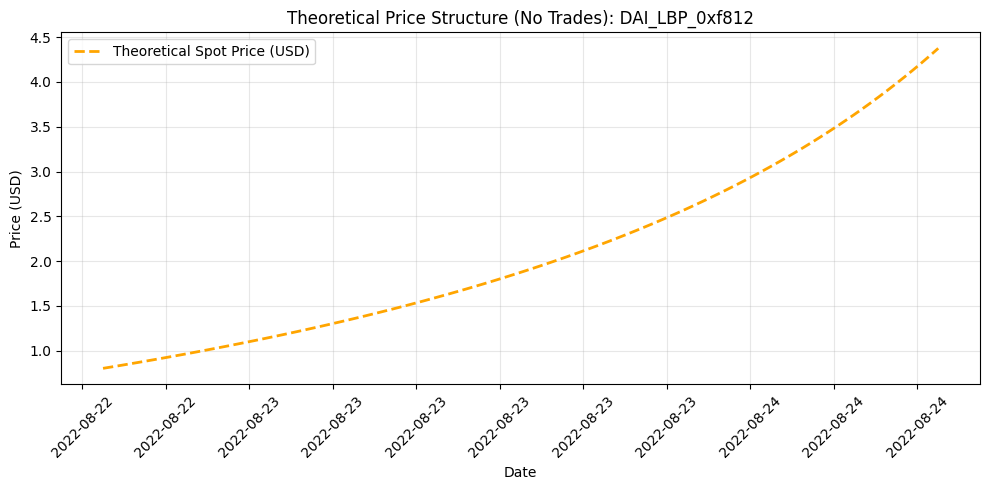

In [3]:
# ==========================================
# 1. HELPER: Fetch Historical ETH Price
# ==========================================
def fetch_usd_history_robust(symbol, start_date, end_date):
    """Fetches USD price history ensuring we cover the full window."""
    try:
        # We only need ETH history for WETH pools
        if symbol != 'WETH': return None
        
        print(f" > Fetching ETH-USD history from {start_date.date()} to {end_date.date()}...")
        
        # Add buffer to dates to ensure coverage
        s_str = (start_date - timedelta(days=5)).strftime('%Y-%m-%d')
        e_str = (end_date + timedelta(days=5)).strftime('%Y-%m-%d')
        
        data = yf.download("ETH-USD", start=s_str, end=e_str, progress=False)
        
        if data.empty: 
            print("   ! Error: YFinance returned no data.")
            return None
            
        # Handle MultiIndex if necessary
        if isinstance(data.columns, pd.MultiIndex):
            data = data['Close']
        else:
            data = data[['Close']]
            
        df = data.reset_index()
        df.columns = ['timestamp', 'price']
        df['timestamp'] = pd.to_datetime(df['timestamp']).dt.tz_localize(None)
        
        return df.set_index('timestamp')['price']
    except Exception as e:
        print(f"   ! Exception fetching history: {e}")
        return None

# ==========================================
# 2. LOAD DATA
# ==========================================
# Assumes you have the file paths defined or loaded
# If not, uncomment the lines below and adjust paths
# V1V2_POOLS_FILE = 'dev_rLBPs_Final_cleaned_pools_addresses.csv'

df_pools = pd.read_csv(V1V2_POOLS_FILE)
df_pools['start_date'] = pd.to_datetime(df_pools['start_date'])
df_pools['end_date'] = pd.to_datetime(df_pools['end_date'])

# Pre-fetch ETH History for the entire range (2020-2023) to be safe
print("Initializing Data...")
eth_history = fetch_usd_history_robust('WETH', pd.to_datetime("2020-01-01"), pd.to_datetime("2023-01-01"))

# ==========================================
# 3. GENERATE THEORETICAL CURVES
# ==========================================
for _, pool in df_pools.iterrows():
    pname = f"{pool['collateral_symbol']}_LBP_{pool['pool_address'][:6]}"
    print(f"\nGenerating Theoretical Curve for: {pname}")

    # Initial Balances (Fixed for Theoretical Calculation)
    const_bal_col = pool['collateral_balance']
    const_bal_proj = pool['project_balance']
    
    # Weights
    w_col_start = pool['collateral_start_weight'] / 100.0
    w_col_end = pool['collateral_end_weight'] / 100.0
    
    # Generate Time Points (100 steps from Start to End)
    total_seconds = (pool['end_date'] - pool['start_date']).total_seconds()
    time_steps = np.linspace(0, total_seconds, 100)
    
    theoretical_curve = []
    
    for t in time_steps:
        # Calculate Timestamp
        curr_ts = pool['start_date'] + timedelta(seconds=t)
        
        # 1. Interpolate Weight (Linear)
        progress = t / total_seconds
        w_col_curr = w_col_start + (w_col_end - w_col_start) * progress
        w_proj_curr = 1.0 - w_col_curr
        
        # 2. Calculate Spot Price (Standard Balancer Formula)
        # Price = (Bal_Col / W_Col) / (Bal_Proj / W_Proj)
        # Note: We use CONSTANT balances here
        if w_col_curr <= 0 or w_proj_curr <= 0:
            raw_price = 0
        else:
            raw_price = (const_bal_col / w_col_curr) / (const_bal_proj / w_proj_curr)
            
        # 3. Convert to USD
        usd_price = raw_price
        
        # Only convert if Collateral is WETH and we have history
        if pool['collateral_symbol'] == 'WETH' and eth_history is not None:
            try:
                # Find nearest ETH price for this specific timestamp
                day_key = curr_ts.replace(hour=0, minute=0, second=0, microsecond=0)
                
                # Fast lookup
                if day_key in eth_history.index:
                    eth_price = eth_history.loc[day_key]
                else:
                    # Fallback to nearest
                    idx = eth_history.index.get_indexer([day_key], method='nearest')[0]
                    eth_price = eth_history.iloc[idx]
                
                usd_price = raw_price * eth_price
            except Exception:
                pass # Fail silently to raw_price if date issue
        
        theoretical_curve.append({'date': curr_ts, 'price': usd_price})

    # ==========================================
    # 4. PLOT
    # ==========================================
    if theoretical_curve:
        df_viz = pd.DataFrame(theoretical_curve)
        
        plt.figure(figsize=(10, 5))
        plt.plot(df_viz['date'], df_viz['price'], label='Theoretical Spot Price (USD)', color='orange', linestyle='--', linewidth=2)
        
        plt.title(f"Theoretical Price Structure (No Trades): {pname}")
        plt.ylabel("Price (USD)")
        plt.xlabel("Date")
        plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
        plt.xticks(rotation=45)
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()

### Real temporal spot price

Loading Market Values & Trades...

Processing Real Price & Volume for: ICHI (WETH LBP)...


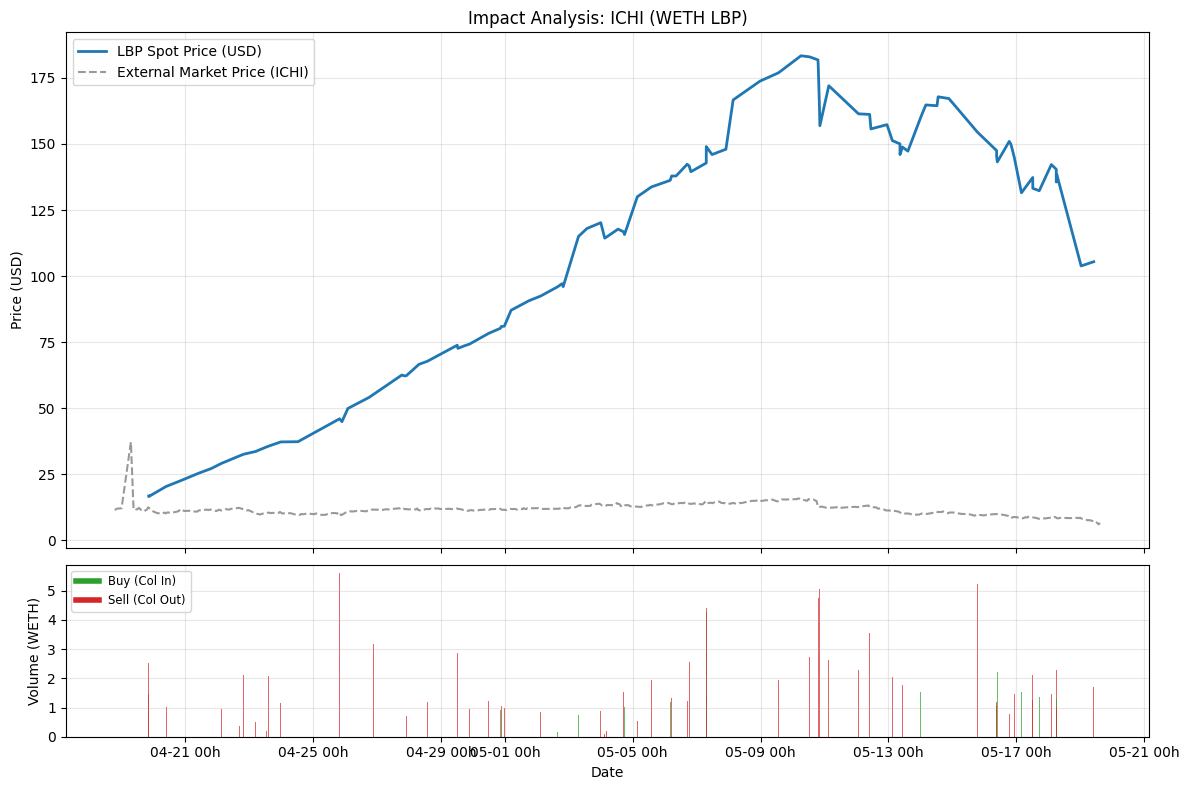


Processing Real Price & Volume for: IDLE (WETH LBP)...


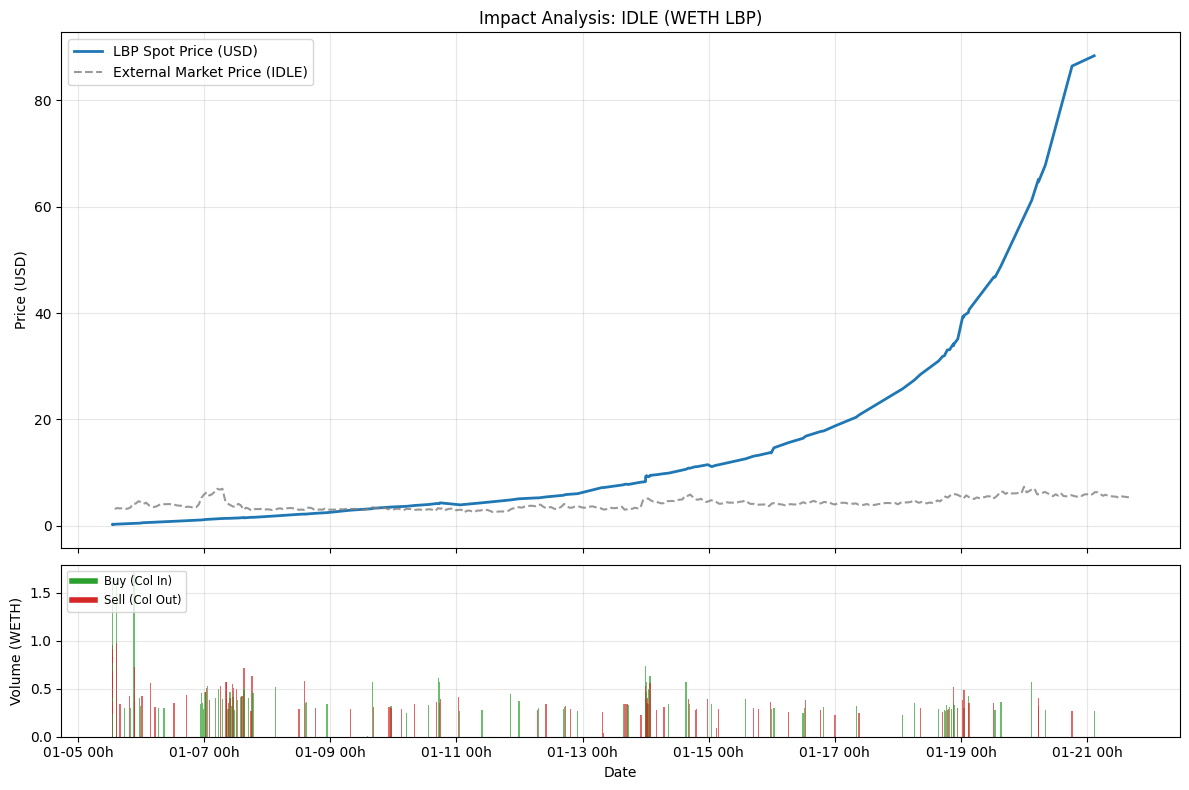


Processing Real Price & Volume for: TEMPLE (DAI LBP)...


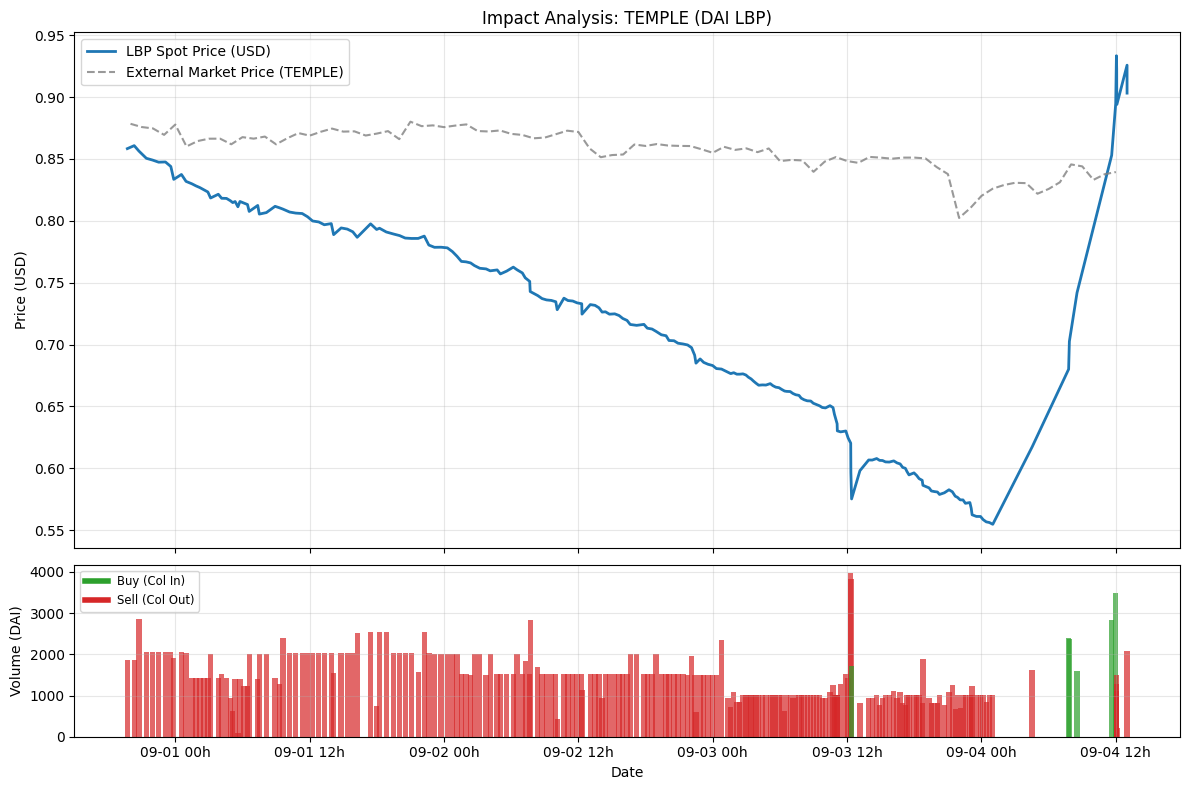


Processing Real Price & Volume for: TEMPLE (DAI LBP)...


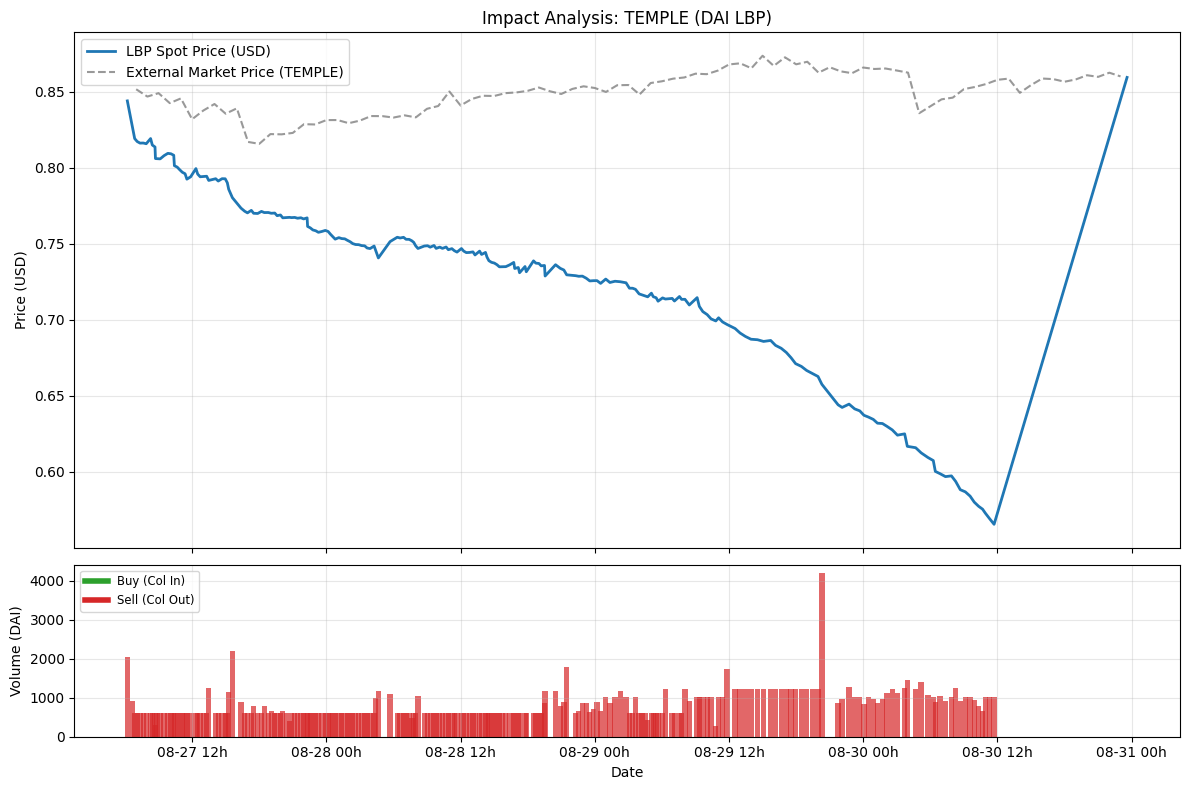


Processing Real Price & Volume for: TEMPLE (DAI LBP)...


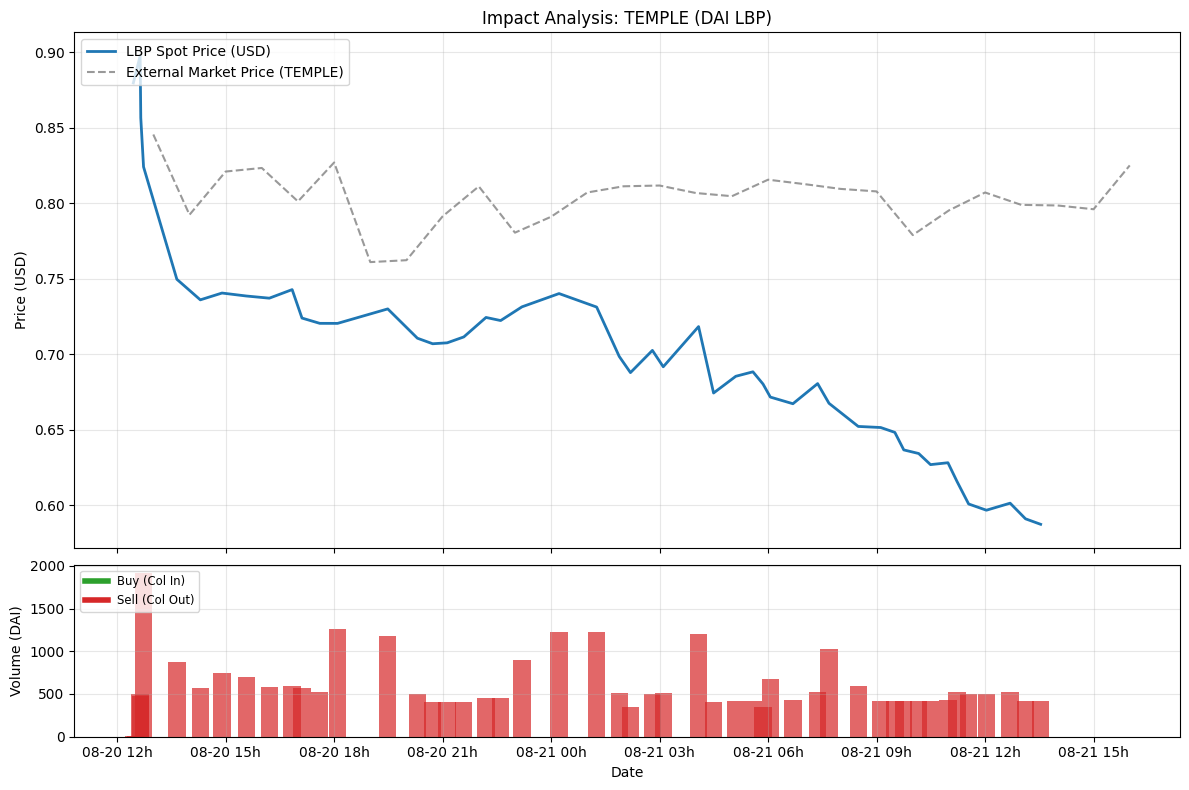


Processing Real Price & Volume for: TEMPLE (DAI LBP)...


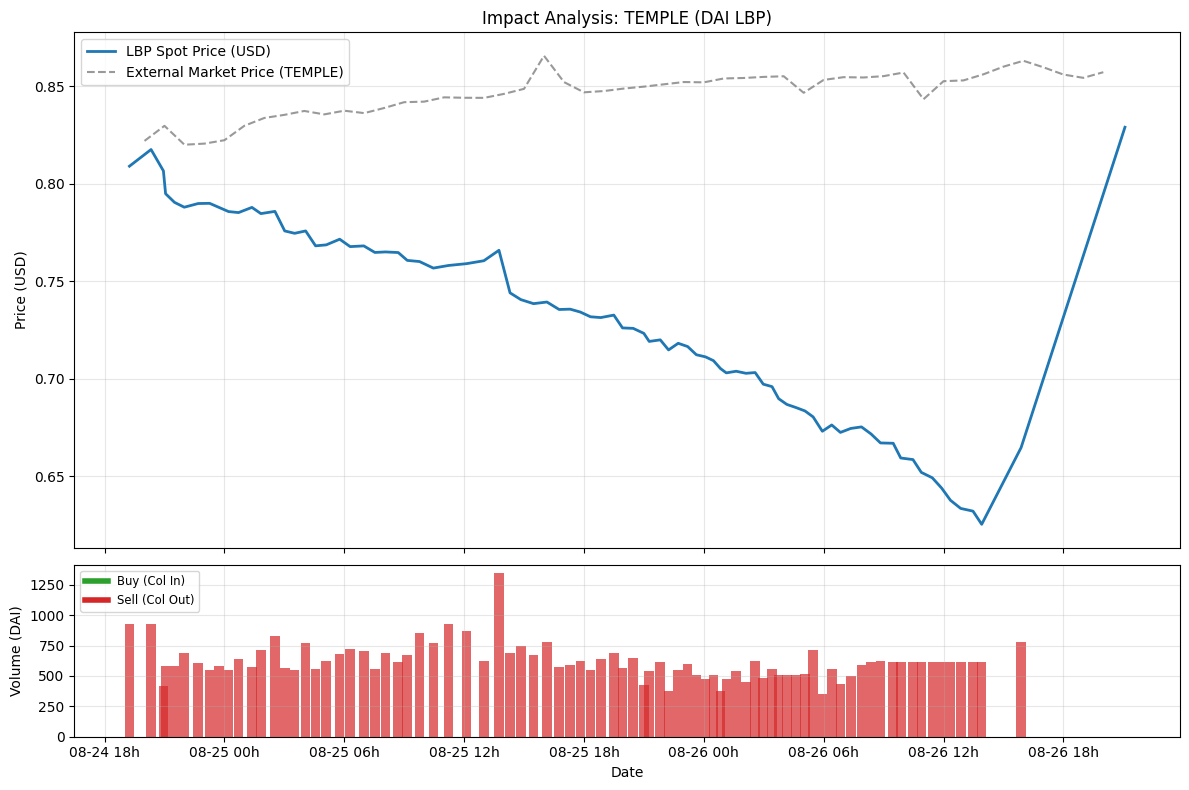


Processing Real Price & Volume for: TEMPLE (DAI LBP)...


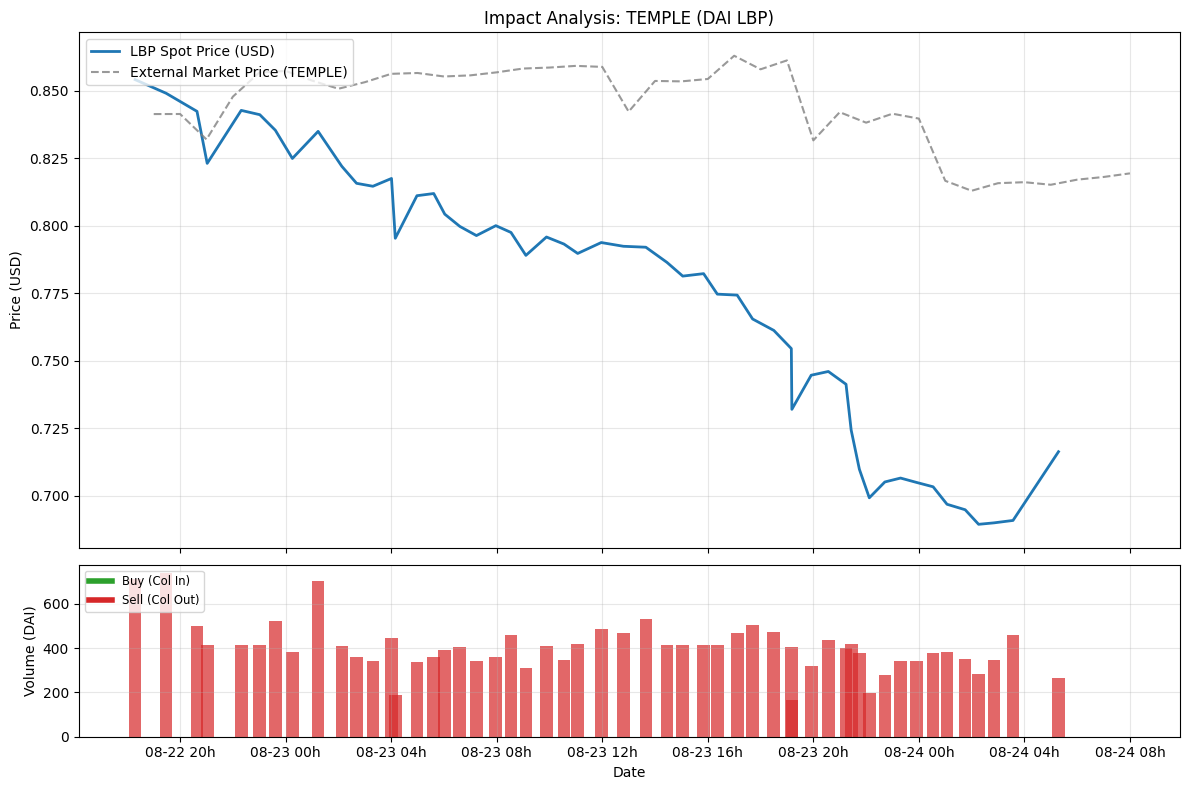

In [4]:
# ==========================================
# REAL TEMPORAL SPOT PRICE (WITH TRADES & VOLUME)
# ==========================================

# 1. SETUP & CONSTANTS
# Define WETH partial address for matching (lowercase, no 0x)
WETH_ADDR_PART = "c02aaa39b223fe8d0a0e5c4f27ead9083c756cc2" 

# Map Pool Address to Token Symbol for Market Data Lookup
POOL_SYMBOL_MAP = {
    '0x903bef1736cddf2a537176cf3c64579c3867a881': 'ICHI',
    '0x875773784af8135ea0ef43b5a374aad105c5d39e': 'IDLE',
    '0x470ebf5f030ed85fc1ed4c2d36b9dd02e77cf1b7': 'TEMPLE'
}

# 2. LOAD DATA (Using Global Constants)
print("Loading Market Values & Trades...")
# Using the variables defined in your previous cells
df_trades = pd.read_csv(V1V2_TRADES_FILE)
df_market = pd.read_csv(V1V2_MARKET_FILE)

df_market['hour'] = pd.to_datetime(df_market['hour']).dt.tz_localize(None)
df_trades['poolId'] = df_trades['poolId'].str.lower()

# Check ETH History (Ensure fetch from previous cells exists)
if 'eth_history' not in globals() or eth_history is None:
    print(" ! ETH History not found. Attempting to fetch...")
    try:
        eth_history = fetch_usd_history_robust('WETH', pd.to_datetime("2020-01-01"), pd.to_datetime("2023-01-01"))
    except:
        print(" ! Could not fetch ETH history. Prices will be in WETH.")

# ==========================================
# PROCESSING LOOP
# ==========================================
for _, pool in df_pools.iterrows():
    pid = pool['poolId']
    addr_clean = pool['pool_address'].lower()
    
    # Identify Symbol
    proj_symbol = POOL_SYMBOL_MAP.get(pool['project_token_address'], "UNKNOWN")
    if proj_symbol == "UNKNOWN": # Fallback check by substring
        for k, v in POOL_SYMBOL_MAP.items():
            if k.lower() in addr_clean:
                proj_symbol = v
                break
            
    pname = f"{proj_symbol} ({pool['collateral_symbol']} LBP)"
    print(f"\nProcessing Real Price & Volume for: {pname}...")

    # 1. SETUP BALANCES
    curr_bal_col = pool['collateral_balance']
    curr_bal_proj = pool['project_balance']
    
    # Weights
    w_col_start = pool['collateral_start_weight'] / 100.0
    w_col_end = pool['collateral_end_weight'] / 100.0
    total_time = (pool['end_date'] - pool['start_date']).total_seconds()
    
    # Decimals
    col_sym = pool['collateral_symbol']
    dec_col = DECIMALS.get(col_sym, 18)
    dec_proj = 18 

    # 2. FILTER TRADES
    pool_trades = df_trades[df_trades['poolId'] == pid].copy()
    pool_trades = pool_trades.sort_values('block_number')
    
    real_curve = []
    volume_data = [] # To store (date, volume, color)
    
    # 3. REPLAY TRADES
    for _, trade in pool_trades.iterrows():
        # A. Calculate Time/Weight Progress
        block_progress = (trade['block_number'] - pool['start_block_approx']) / (pool['end_block_est'] - pool['start_block_approx'])
        block_progress = max(0, min(1, block_progress))
        
        time_offset = total_time * block_progress
        curr_ts = pool['start_date'] + timedelta(seconds=time_offset)
        
        w_col_curr = w_col_start + (w_col_end - w_col_start) * block_progress
        w_proj_curr = 1.0 - w_col_curr
        
        # B. Calculate Spot Price
        if curr_bal_proj > 0 and w_col_curr > 0:
            raw_price = (curr_bal_col / w_col_curr) / (curr_bal_proj / w_proj_curr)
        else:
            raw_price = 0
            
        # C. Convert to USD
        usd_price = raw_price
        if col_sym == 'WETH' and eth_history is not None:
            try:
                day_key = curr_ts.replace(hour=0, minute=0, second=0, microsecond=0)
                # Fast lookup with fallback
                if day_key in eth_history.index:
                    eth_price = eth_history.loc[day_key]
                else:
                    idx = eth_history.index.get_indexer([day_key], method='nearest')[0]
                    eth_price = eth_history.iloc[idx]
                usd_price = raw_price * eth_price
            except:
                pass 
        elif col_sym in ['DAI', 'USDC', 'USDT']:
             usd_price = raw_price # Stablecoins
        
        real_curve.append({'date': curr_ts, 'price': usd_price})
        
        # D. UPDATE BALANCES & CALCULATE VOLUME
        try:
            data_clean = trade['data'].replace('0x', '')
            if len(data_clean) >= 128:
                # Raw amounts (Hex -> Int)
                amt0_raw = int(data_clean[0:64], 16) # Amount IN
                amt1_raw = int(data_clean[64:128], 16) # Amount OUT
                
                # Check Direction
                topic1 = str(trade['topic1_token_in']).lower()
                
                # If Collateral (WETH) is the Token In -> It is a BUY
                is_buy = False
                if WETH_ADDR_PART in topic1 or (col_sym == 'DAI' and '6b1754' in topic1):
                    is_buy = True
                    
                    # Update Balances
                    curr_bal_col += amt0_raw / (10**dec_col)
                    curr_bal_proj -= amt1_raw / (10**dec_proj)
                    
                    # Volume is the WETH Amount In
                    vol_weth = amt0_raw / (10**dec_col)
                    volume_data.append({'date': curr_ts, 'vol': vol_weth, 'type': 'Buy', 'color': '#2ca02c'}) # Green
                else:
                    # It is a SELL (Collateral Out)
                    is_buy = False
                    
                    # Update Balances
                    curr_bal_proj += amt0_raw / (10**dec_proj)
                    curr_bal_col -= amt1_raw / (10**dec_col)
                    
                    # Volume is the WETH Amount Out
                    vol_weth = amt1_raw / (10**dec_col)
                    volume_data.append({'date': curr_ts, 'vol': vol_weth, 'type': 'Sell', 'color': '#d62728'}) # Red
                    
        except Exception as e:
            continue

    # ==========================================
    # 4. PLOTTING (Dual Axis: Price + Volume)
    # ==========================================
    if real_curve:
        df_real = pd.DataFrame(real_curve)
        df_vol = pd.DataFrame(volume_data)
        
        # Create Subplots (Price on top, Volume on bottom)
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True, gridspec_kw={'height_ratios': [3, 1]})
        
        # --- AX1: Prices ---
        # 1. LBP Price
        ax1.plot(df_real['date'], df_real['price'], label='LBP Spot Price (USD)', color='#1f77b4', linewidth=2)
        
        # 2. Market Price
        if proj_symbol != "UNKNOWN":
            mask = df_market['symbol'] == proj_symbol
            mask_date = (df_market['hour'] >= pool['start_date']) & (df_market['hour'] <= pool['end_date'])
            df_ext = df_market[mask & mask_date].sort_values('hour')
            
            if not df_ext.empty:
                ax1.plot(df_ext['hour'], df_ext['market_price_avg'], 
                         label=f'External Market Price ({proj_symbol})', 
                         color='gray', linestyle='--', alpha=0.8)
        
        ax1.set_title(f"Impact Analysis: {pname}")
        ax1.set_ylabel("Price (USD)")
        ax1.legend(loc='upper left')
        ax1.grid(True, alpha=0.3)
        
        # --- AX2: Volume ---
        if not df_vol.empty:
            # We use bar chart for volume
            # Note: width needs to be small for time-series bars
            width_days = 0.02 # Approx 30 mins width visually
            ax2.bar(df_vol['date'], df_vol['vol'], color=df_vol['color'], width=width_days, alpha=0.7)
            
            # Create Custom Legend for Volume
            from matplotlib.lines import Line2D
            custom_lines = [Line2D([0], [0], color='#2ca02c', lw=4),
                            Line2D([0], [0], color='#d62728', lw=4)]
            ax2.legend(custom_lines, ['Buy (Col In)', 'Sell (Col Out)'], loc='upper left', fontsize='small')
            
        ax2.set_ylabel(f"Volume ({col_sym})")
        ax2.set_xlabel("Date")
        ax2.grid(True, alpha=0.3)
        
        # Formatting
        ax1.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %Hh'))
        plt.xticks(rotation=0)
        plt.tight_layout()
        plt.subplots_adjust(hspace=0.05) # Reduce gap between plots
        plt.show()

## Evaluate the rLBP success based on its theorical benefits

### Article listed benefits

Running Final Evaluation...

=== FINAL rLBP PERFORMANCE REPORT ===
       Pool  Bot_Score  Fair_Val  Stability  Cost_Eff  Final_GPA
 DAI-0xbaed       94.5      98.1       94.5         0       71.8
 DAI-0xe11b       91.0      98.9       93.6         0       70.9
 DAI-0x174c       97.1      93.4       92.7         0       70.8
 DAI-0xd328       99.8      97.2       77.2         0       68.5
 DAI-0xf812       83.4      95.8       90.9         0       67.5
WETH-0x4693       92.7      52.5       39.8         0       46.3
WETH-0xa4a8       99.4       0.0        0.0         0       24.9


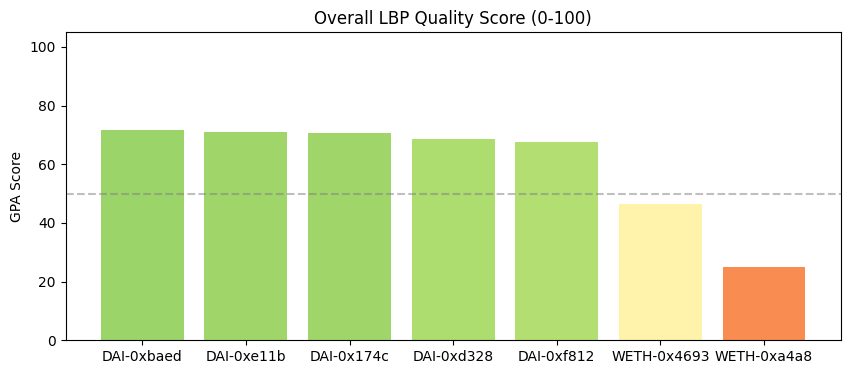

In [ ]:
# ==========================================
# 1. METRIC CALCULATOR ENGINE
# ==========================================

def calculate_metrics(df_trades, pool_meta):
    """
    Calculates the 4 key metrics for a Reverse LBP.
    Expects df_trades to have: ['block_number', 'timestamp', 'exec_price', 'spot_price', 'amount_usd', 'side']
    """
    if df_trades.empty:
        return {k: 0 for k in ['Bot_Score', 'Fair_Val', 'Stability', 'Cost_Eff', 'Final_GPA']}

    # --- METRIC 1: BOT & DUMP RESISTANCE (Corrected) ---
    # Old Way: Penalized ALL volume (Bad for rLBP).
    # New Way: Penalize only SELL volume in the first 50 blocks (~10 mins).
    start_block = df_trades['block_number'].min()
    early_window = df_trades[df_trades['block_number'] <= start_block + 50]
    
    if not early_window.empty:
        early_sell_vol = early_window[early_window['side'] == 'SELL']['amount_usd'].sum()
        total_vol = df_trades['amount_usd'].sum()
        
        # If >20% of total volume is dumped in first 10 mins, Score = 0.
        # Otherwise, scale linearly.
        dump_ratio = (early_sell_vol / total_vol) if total_vol > 0 else 0
        bot_score = max(0, 100 - (dump_ratio * 500)) # 20% dump = 100 penalty
    else:
        bot_score = 100 # No early activity = No bots

    # --- METRIC 2: FAIR VALUE DISCOVERY ---
    # Compare LBP Close Price vs. Post-LBP Price (Stability check)
    # We take the average of the last 10 trades as "Close Price"
    close_price = df_trades.tail(10)['exec_price'].mean()
    
    # Ideally we'd look at future data, but using available data:
    # If the price trended UP and held, it's good. 
    # We penalize volatility in the second half.
    second_half = df_trades.iloc[len(df_trades)//2:]
    if not second_half.empty:
        price_dev = second_half['exec_price'].std() / second_half['exec_price'].mean()
        fair_val_score = max(0, 100 - (price_dev * 200)) # 50% deviation = 0 score
    else:
        fair_val_score = 50 # Neutral if no data

    # --- METRIC 3: MARKET STABILITY ---
    # Measures chaos/volatility per trade
    returns = df_trades['exec_price'].pct_change().dropna()
    volatility = returns.std()
    stability_score = max(0, 100 - (volatility * 1000))

    # --- METRIC 4: COST EFFICIENCY (Corrected) ---
    # Old Way: Compared to Market Price (Arbitrage).
    # New Way: Compare Exec Price vs. Spot Price (Slippage/Impact).
    # Formula: |(Exec - Spot) / Spot|
    
    # Filter out tiny dust trades that might have weird pricing
    valid_trades = df_trades[df_trades['amount_usd'] > 10] 
    
    if not valid_trades.empty:
        slippage = (valid_trades['exec_price'] - valid_trades['spot_price']).abs() / valid_trades['spot_price']
        avg_slippage = slippage.mean()
        
        # 5% average slippage = Score 0. 
        # 0.5% average slippage = Score 90.
        cost_score = max(0, 100 - (avg_slippage * 2000))
    else:
        cost_score = 100

    # --- FINAL GPA ---
    final_gpa = (bot_score * 0.25) + (fair_val_score * 0.25) + (stability_score * 0.25) + (cost_score * 0.25)
    
    return {
        'Bot_Score': round(bot_score, 1),
        'Fair_Val': round(fair_val_score, 1),
        'Stability': round(stability_score, 1),
        'Cost_Eff': round(cost_score, 1),
        'Final_GPA': round(final_gpa, 1)
    }

# ==========================================
# 2. DATA ENRICHMENT LOOP (Generates Spot Price)
# ==========================================
eval_results = []

print("Running Final Evaluation...")

for _, pool in df_pools.iterrows():
    pid = pool['poolId']
    
    # Filter Trades
    pool_trades = df_trades[df_trades['poolId'] == pid].copy()
    if pool_trades.empty: continue
    
    pool_trades = pool_trades.sort_values('block_number')
    
    # Initialize Replay for Spot Price Calculation
    curr_bal_col = pool['collateral_balance']
    curr_bal_proj = pool['project_balance']
    w_col_start = pool['collateral_start_weight'] / 100.0
    w_col_end = pool['collateral_end_weight'] / 100.0
    total_time = (pool['end_date'] - pool['start_date']).total_seconds()
    
    col_sym = pool['collateral_symbol']
    dec_col = DECIMALS.get(col_sym, 18)
    dec_proj = 18
    
    rich_data = []
    
    # --- REPLAY TO GENERATE METRICS DATA ---
    for _, trade in pool_trades.iterrows():
        # A. Calc Weights
        block_prog = (trade['block_number'] - pool['start_block_approx']) / (pool['end_block_est'] - pool['start_block_approx'])
        block_prog = max(0, min(1, block_prog))
        
        # B. Calc Spot Price (Pre-Trade)
        w_col = w_col_start + (w_col_end - w_col_start) * block_prog
        w_proj = 1.0 - w_col
        
        if curr_bal_proj > 0 and w_col > 0:
            spot_price_native = (curr_bal_col / w_col) / (curr_bal_proj / w_proj)
        else:
            spot_price_native = 0
            
        # USD Conversion
        eth_p = 2000 # Fallback
        if col_sym == 'WETH' and eth_history is not None:
            try:
                ts = pd.to_datetime(pool['start_date']) + timedelta(seconds=total_time*block_prog)
                day = ts.replace(hour=0, minute=0, second=0, microsecond=0)
                if day in eth_history.index: eth_p = eth_history.loc[day]
            except: pass
            spot_price_usd = spot_price_native * eth_p
        elif col_sym in ['DAI', 'USDC']:
            spot_price_usd = spot_price_native
        else:
            spot_price_usd = 0 # Skip weird pools
            
        # C. Parse Execution & Side
        try:
            data = trade['data'].replace('0x', '')
            amt0 = int(data[0:64], 16)
            amt1 = int(data[64:128], 16)
            
            # Identify Side
            topic1 = str(trade['topic1_token_in']).lower()
            if WETH_ADDR_PART in topic1 or (col_sym == 'DAI' and '6b1754' in topic1):
                side = 'BUY'
                curr_bal_col += amt0 / (10**dec_col)
                curr_bal_proj -= amt1 / (10**dec_proj)
                
                amount_usd = (amt0 / (10**dec_col)) * (eth_p if col_sym=='WETH' else 1)
                
                # Exec Price = Amount Paid / Amount Received
                if amt1 > 0:
                    exec_price_usd = amount_usd / (amt1 / 10**dec_proj)
                else:
                    exec_price_usd = spot_price_usd
            else:
                side = 'SELL'
                curr_bal_proj += amt0 / (10**dec_proj)
                curr_bal_col -= amt1 / (10**dec_col)
                
                amount_usd = (amt1 / (10**dec_col)) * (eth_p if col_sym=='WETH' else 1)
                
                if amt0 > 0:
                    exec_price_usd = amount_usd / (amt0 / 10**dec_proj)
                else:
                    exec_price_usd = spot_price_usd

            rich_data.append({
                'block_number': trade['block_number'],
                'timestamp': trade['block_number'], # Proxy
                'spot_price': spot_price_usd,
                'exec_price': exec_price_usd,
                'amount_usd': amount_usd,
                'side': side
            })
            
        except:
            continue

    # --- CALCULATE SCORES ---
    df_rich = pd.DataFrame(rich_data)
    scores = calculate_metrics(df_rich, pool)
    
    # Add Identity
    scores['Pool'] = f"{pool['collateral_symbol']}-{pool['pool_address'][:6]}"
    eval_results.append(scores)

# ==========================================
# 3. DISPLAY RESULTS
# ==========================================
results_df = pd.DataFrame(eval_results)
if not results_df.empty:
    # Reorder columns
    cols = ['Pool', 'Bot_Score', 'Fair_Val', 'Stability', 'Cost_Eff', 'Final_GPA']
    results_df = results_df[cols].sort_values('Final_GPA', ascending=False)
    
    print("\n=== FINAL rLBP PERFORMANCE REPORT ===")
    print(results_df.to_string(index=False))
    
    # Optional: Plot GPA
    plt.figure(figsize=(10, 4))
    plt.bar(results_df['Pool'], results_df['Final_GPA'], color=plt.cm.RdYlGn(results_df['Final_GPA'] / 100))
    plt.title("Overall LBP Quality Score (0-100)")
    plt.ylabel("GPA Score")
    plt.axhline(50, color='gray', linestyle='--', alpha=0.5)
    plt.ylim(0, 105)
    plt.show()
else:
    print("No data to evaluate.")

--- INICIANDO ANÁLISE DE EFICIÊNCIA DE BUYBACK (CORRIGIDA) ---



C:\Users\kaiqu\AppData\Local\Temp\ipykernel_9656\2129852389.py:217: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='size_bucket', y='markout_1h', data=df_res, ax=ax3, palette="RdYlGn")


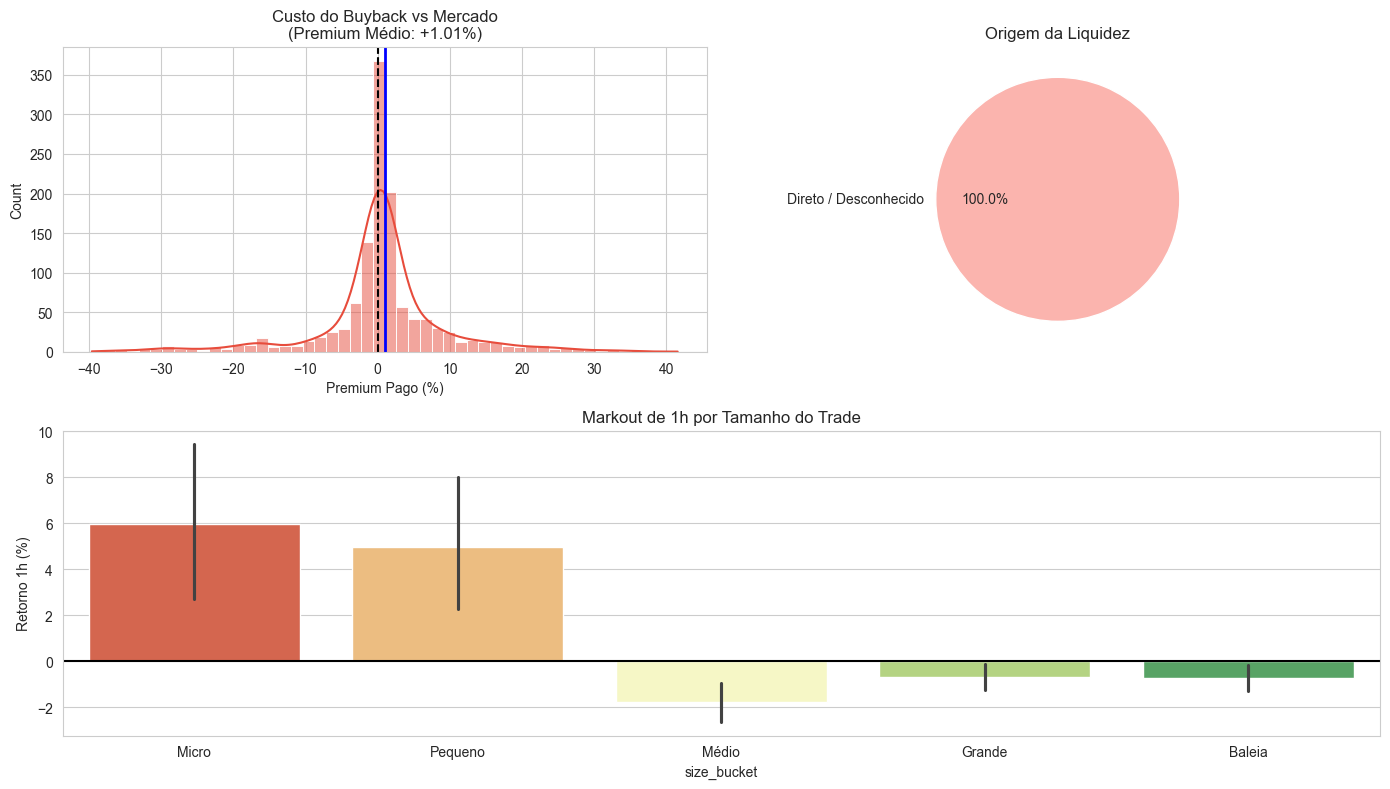

      RELATÓRIO DE EFICIÊNCIA DO rLBP (CORRIGIDO)      
Volume Total Analisado:   $1,214,563.78
------------------------------------------------------------
1. CUSTO DE EXECUÇÃO (Premium vs Mercado)
   Média Ponderada:       +1.01%
   >> O Pool pagou 1.01% ACIMA do mercado (Custo).

2. EFICIÊNCIA DE INVENTÁRIO (Markout 1h)
   Retorno após 1h:       -0.82%


In [ ]:
# ==========================================
# 1. CONFIGURATION
# ==========================================
KNOWN_ROUTERS = {
    '0x1111111254fb6c44baca0b5c94751821156db930': '1inch v4',
    '0x11111112542d85b3ef69ae05771c2dccff4faa26': '1inch v5',
    '0x9008d19f58aabd9332f9815c77c8b8cf84258491': 'CoW Protocol',
    '0xdef171fe48cf0115b1d80b88dc8eab59176fee57': 'ParaSwap',
    '0x68b3465833fb72a70ecdf485e0e4c7bd8665fc45': 'Uniswap V3',
    '0x7a250d5630b4cf539739df2c5dacb4c659f2488d': 'Uniswap V2',
    '0x881d40237659c251811cec9c364ef91dc08d300c': 'Metamask Swap',
}

KNOWN_MEV_BOTS = {
    '0xae2fc483527b8ef99eb5d9b44875f005ba1fae13': 'JaredFromSubway',
    '0x6b75d8af000000e20b7a7ddf000ba900b4009a80': 'MEV Bot A',
}

# --- CRITICAL FIX: DECIMALS MAP ---
# ICHI v1 has 9 decimals. Most others have 18.
PROJECT_DECIMALS = {
    'ICHI': 9,
    'IDLE': 18,
    'TEMPLE': 18
}

POOL_SYMBOL_MAP = {
    '0x46935b2489d1468a580ccc3ccba11d1eb7737199': 'ICHI',
    '0xa4a8a79295fa8d0da16b557a9dcad290ff3da321': 'IDLE',
    '0x174cfa15a24f3fc49fc2bc66b5e6046e549557c9': 'TEMPLE',
    '0xbaed9f622f88c1b3f79ca5f4bf57688580951fa3': 'TEMPLE',
    '0xd328ffd19422585537a843e278490a8b21627216': 'TEMPLE',
    '0xe11b6a3fa1e69ab2d9aa872701cfb32decec6d41': 'TEMPLE',
    '0xf812a0565b1d396c1518ff547d23f6dc27c53686': 'TEMPLE'
}

DECIMALS = {'WETH': 18, 'DAI': 18, 'USDC': 6}

# ==========================================
# 2. HELPER FUNCTIONS
# ==========================================
def decode_swap_data(hex_str):
    clean = hex_str.replace('0x', '')
    if len(clean) < 128: return 0, 0
    return int(clean[0:64], 16), int(clean[64:128], 16)

def classify_source(sender_address):
    addr = str(sender_address).lower().replace('0x000000000000000000000000', '0x')
    if addr in KNOWN_ROUTERS: return 'Aggregator (Organic)'
    elif addr in KNOWN_MEV_BOTS: return 'MEV Bot (Arbitragem)'
    else: return 'Direto / Desconhecido'


print("--- INICIANDO ANÁLISE DE EFICIÊNCIA DE BUYBACK (CORRIGIDA) ---\n")

# 1. LOAD DATA
try:
    df_trades = pd.read_csv(V1V2_TRADES_FILE)
    df_market = pd.read_csv(V1V2_MARKET_FILE)
    df_meta = pd.read_csv(V1V2_POOLS_FILE)
    try:
        df_temple = pd.read_csv('rLBPs_BalancerV2_TEMPLE_market_value_2022.csv')
        df_temple['symbol'] = 'TEMPLE'
        df_temple = df_temple[['hour', 'market_price_avg', 'symbol']]
        df_market = pd.concat([df_market, df_temple], ignore_index=True)
    except: pass
except FileNotFoundError:
    print("Erro: Arquivos não encontrados.")
    raise

# 2. PREPARE MARKET DATA
df_market['hour'] = pd.to_datetime(df_market['hour']).dt.tz_localize(None)
df_market = df_market.drop_duplicates(subset=['hour', 'symbol']).sort_values('hour')

market_lookups = {}
for sym, group in df_market.groupby('symbol'):
    market_lookups[sym] = group.set_index('hour')['market_price_avg']

# --- FETCH ETH HISTORY FOR USD CONVERSION ---
if 'eth_history' not in globals() or eth_history is None:
    print(" ! Fetching ETH History for USD conversion...")
    eth_history = fetch_usd_history_robust('WETH', pd.to_datetime("2020-01-01"), pd.to_datetime("2023-01-01"))

# 3. PROCESS TRADES
buyback_trades = []
df_trades['poolId'] = df_trades['poolId'].str.lower()

for _, pool in df_meta.iterrows():
    pid = pool['poolId']
    proj_addr = pool['project_token_address'].lower()
    col_symbol = pool['collateral_symbol']
    col_dec = DECIMALS.get(col_symbol, 18)
    
    proj_symbol = POOL_SYMBOL_MAP.get(pool['pool_address'], POOL_SYMBOL_MAP.get(pool['poolId'], 'UNKNOWN'))
    proj_dec = PROJECT_DECIMALS.get(proj_symbol, 18) # Default to 18 if unknown
    
    pool_trades = df_trades[df_trades['poolId'] == pid].copy().sort_values('block_number')
    
    # Time Interpolation
    t_start = pd.to_datetime(pool['start_date'])
    duration = (pd.to_datetime(pool['end_date']) - t_start).total_seconds()
    pool_trades['progress'] = (pool_trades['block_number'] - pool['start_block_approx']) / \
                              (pool['end_block_est'] - pool['start_block_approx'])
    pool_trades['timestamp'] = t_start + (pool_trades['progress'] * timedelta(seconds=duration))
    
    for idx, row in pool_trades.iterrows():
        amt_in, amt_out = decode_swap_data(row['data'])
        token_in = '0x' + str(row['topic1_token_in']).replace('0x', '')[-40:].lower()
        
        # IF BUYBACK (Token In == Project)
        if token_in == proj_addr:
            # 1. CORRECT DECIMALS
            vol_proj = amt_in / (10**proj_dec)        
            vol_col = amt_out / (10**col_dec)
            
            if vol_proj > 0:
                exec_price_native = vol_col / vol_proj 
                
                # 2. CONVERT TO USD (Fixing the Unit Mismatch)
                eth_price = 1.0
                if col_symbol == 'WETH' and eth_history is not None:
                    try:
                        ts_lookup = row['timestamp'].replace(hour=0, minute=0, second=0, microsecond=0)
                        eth_price = eth_history.loc[ts_lookup]
                    except: eth_price = 2000.0 # Fallback
                
                # If Collateral is Stable (DAI/USDC), eth_price stays 1.0
                price_paid_usd = exec_price_native * eth_price
                volume_usd = vol_col * eth_price

                buyback_trades.append({
                    'timestamp': row['timestamp'],
                    'volume_usd': volume_usd,
                    'price_paid': price_paid_usd,
                    'symbol': proj_symbol,
                    'sender': '0x' + str(row['topic1_token_in']).replace('0x', '')[-40:].lower()
                })

df = pd.DataFrame(buyback_trades)
if df.empty:
    print("Nenhum trade de Buyback encontrado.")
    raise

# 4. METRICS & VISUALIZATION
analysis_data = []

for idx, row in df.iterrows():
    sym = row['symbol']
    lookup = market_lookups.get(sym)
    if lookup is None: continue
    
    try:
        # Market Lookup
        idx_now = lookup.index.get_indexer([row['timestamp']], method='nearest')[0]
        if idx_now == -1: continue
        price_mkt = lookup.iloc[idx_now]
        
        # Premium
        premium_pct = (row['price_paid'] - price_mkt) / price_mkt * 100
        
        # Markout 1h
        t_fut = row['timestamp'] + timedelta(hours=1)
        idx_fut = lookup.index.get_indexer([t_fut], method='nearest')[0]
        price_fut = lookup.iloc[idx_fut]
        markout_pct = (price_fut - row['price_paid']) / row['price_paid'] * 100
        
        analysis_data.append({
            'volume': row['volume_usd'],
            'premium_pct': premium_pct,
            'markout_1h': markout_pct,
            'source': classify_source(row['sender'])
        })
        
    except: pass
    
df_res = pd.DataFrame(analysis_data)
if df_res.empty:
    print("analysis_data is empty")
    raise

# Weighted Averages
total_vol = df_res['volume'].sum()
avg_premium = (df_res['premium_pct'] * df_res['volume']).sum() / total_vol
avg_markout = (df_res['markout_1h'] * df_res['volume']).sum() / total_vol

source_vol = df_res.groupby('source')['volume'].sum()

# Plot
sns.set_style("whitegrid")
fig = plt.figure(figsize=(14, 8))
gs = fig.add_gridspec(2, 2)

ax1 = fig.add_subplot(gs[0, 0])
# Filter outliers for plotting (keep 98% of data visible)
p_low, p_high = np.percentile(df_res['premium_pct'], [1, 99])
df_plot = df_res[(df_res['premium_pct'] > p_low) & (df_res['premium_pct'] < p_high)]

sns.histplot(df_plot['premium_pct'], bins=50, kde=True, ax=ax1, color='#e74c3c')
ax1.axvline(0, color='black', linestyle='--')
ax1.axvline(avg_premium, color='blue', linestyle='-', linewidth=2)
ax1.set_title(f"Custo do Buyback vs Mercado\n(Premium Médio: {avg_premium:+.2f}%)")
ax1.set_xlabel("Premium Pago (%)")

ax2 = fig.add_subplot(gs[0, 1])
if not source_vol.empty:
    source_vol.plot.pie(autopct='%1.1f%%', ax=ax2, cmap='Pastel1', ylabel='')
    ax2.set_title("Origem da Liquidez")

ax3 = fig.add_subplot(gs[1, :])
df_res['size_bucket'] = pd.qcut(df_res['volume'], 5, labels=["Micro", "Pequeno", "Médio", "Grande", "Baleia"])
sns.barplot(x='size_bucket', y='markout_1h', data=df_res, ax=ax3, palette="RdYlGn")
ax3.axhline(0, color='black')
ax3.set_title("Markout de 1h por Tamanho do Trade")
ax3.set_ylabel("Retorno 1h (%)")

plt.tight_layout()
plt.show()

print("="*60)
print("      RELATÓRIO DE EFICIÊNCIA DO rLBP      ")
print("="*60)
print(f"Volume Total Analisado:   ${total_vol:,.2f}")
print("-" * 60)
print("1. CUSTO DE EXECUÇÃO (Premium vs Mercado)")
print(f"   Média Ponderada:       {avg_premium:+.2f}%")
if avg_premium > 0:
    print(f"   >> O Pool pagou {avg_premium:.2f}% ACIMA do mercado (Custo).")
else:
    print(f"   >> O Pool pagou {abs(avg_premium):.2f}% ABAIXO do mercado (Economia).")

print("\n2. EFICIÊNCIA DE INVENTÁRIO (Markout 1h)")
print(f"   Retorno após 1h:       {avg_markout:+.2f}%")
print("="*60)
